# Exploratory Data Analysis (EDA) Project
### Heart Disease Dataset (Cleveland)

**Student Name:** Siddharth Singh  
**Roll Number:** DSBA-T12/AUG-11532  
**Program:** Data Science & Business Analytics Traineeship — InternsElite  
**Mentor:** Mr. Ayush Shrivastav

**Objective:** Perform an in-depth Exploratory Data Analysis (EDA) on a dataset of choice to gain meaningful insights, identify patterns, trends, and relationships within the data.

## 1. Dataset Selection

**Dataset:** Heart Disease (Cleveland) Dataset  
**Source:** Originally published on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease). The UCI site was not directly reachable from the execution environment used to build this notebook, so the identical published dataset was retrieved from a public GitHub mirror of the same UCI file (`dataprofessor/data`).

This dataset was chosen because it is a classic medical dataset with a strong mix of numeric clinical measurements (age, cholesterol, blood pressure, heart rate) and categorical clinical codes (chest pain type, ECG results, thalassemia test), real missing values, and a clear target variable — heart disease diagnosis — making it excellent for demonstrating cleaning, preprocessing, and insight-driven EDA.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 2. Data Import & Export

In [30]:
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"
df = pd.read_csv(url)
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,diagnosis
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   cp         303 non-null    int64  
 3   trestbps   303 non-null    int64  
 4   chol       303 non-null    int64  
 5   fbs        303 non-null    int64  
 6   restecg    303 non-null    int64  
 7   thalach    303 non-null    int64  
 8   exang      303 non-null    int64  
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    int64  
 11  ca         303 non-null    object 
 12  thal       303 non-null    object 
 13  diagnosis  303 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 33.3+ KB


In [32]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
diagnosis    0
dtype: int64

## 3. Data Cleaning

- Remove unnecessary/redundant columns
- Rename columns for clarity
- Handle missing/null values
- Remove duplicate rows

In [33]:
df_clean = df.copy()

# All 13 clinical attributes plus the diagnosis label carry independent
# medical information, so no columns need to be dropped as "redundant" here.
df_clean.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'diagnosis']

In [34]:
# Rename columns for clarity
df_clean = df_clean.rename(columns={
    "cp": "chest_pain_type",
    "trestbps": "resting_bp",
    "chol": "cholesterol",
    "fbs": "fasting_blood_sugar_high",
    "restecg": "resting_ecg",
    "thalach": "max_heart_rate",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "num_major_vessels",
    "thal": "thalassemia",
    "diagnosis": "heart_disease_stage",
})
df_clean.columns.tolist()

['age',
 'sex',
 'chest_pain_type',
 'resting_bp',
 'cholesterol',
 'fasting_blood_sugar_high',
 'resting_ecg',
 'max_heart_rate',
 'exercise_induced_angina',
 'st_depression',
 'st_slope',
 'num_major_vessels',
 'thalassemia',
 'heart_disease_stage']

In [35]:
# Handle missing values - '?' marks missing values in ca / thal
df_clean["num_major_vessels"] = pd.to_numeric(df_clean["num_major_vessels"], errors="coerce")
df_clean["thalassemia"] = pd.to_numeric(df_clean["thalassemia"], errors="coerce")
print("Missing values before imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values before imputation:
num_major_vessels    4
thalassemia          2
dtype: int64


In [36]:
# Impute with the mode, since both fields are discrete/categorical-coded
df_clean["num_major_vessels"] = df_clean["num_major_vessels"].fillna(df_clean["num_major_vessels"].mode()[0])
df_clean["thalassemia"] = df_clean["thalassemia"].fillna(df_clean["thalassemia"].mode()[0])
df_clean.isnull().sum().sum()

np.int64(0)

In [37]:
# Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows. New shape: {df_clean.shape}")

Removed 0 duplicate rows. New shape: (303, 14)


## 4. Data Preprocessing

- Convert data types where needed
- Remove/handle outliers
- Encode categorical variables
- Additional feature engineering for this dataset

In [38]:
# Convert data types
df_clean["num_major_vessels"] = df_clean["num_major_vessels"].astype(int)
df_clean["thalassemia"] = df_clean["thalassemia"].astype(int)
df_clean["sex"] = df_clean["sex"].astype(int)

# Simplify the multi-class diagnosis (0-4) into a standard binary target
df_clean["has_heart_disease"] = (df_clean["heart_disease_stage"] > 0).astype(int)
df_clean[["heart_disease_stage", "has_heart_disease"]].head()

,heart_disease_stage,has_heart_disease
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [39]:
# Handle outliers in cholesterol and resting BP using the IQR method (cap, don't drop)
for col in ["cholesterol", "resting_bp"]:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f"Capped {n_out} outliers in {col}")

Capped 5 outliers in cholesterol
Capped 9 outliers in resting_bp


In [40]:
# Encode categorical/labeled variables for readable charts
df_clean["sex_label"] = df_clean["sex"].map({1: "Male", 0: "Female"})
df_clean["chest_pain_label"] = df_clean["chest_pain_type"].map({
    1: "Typical Angina", 2: "Atypical Angina", 3: "Non-anginal Pain", 4: "Asymptomatic"
})
df_clean["thal_label"] = df_clean["thalassemia"].map({3: "Normal", 6: "Fixed Defect", 7: "Reversible Defect"})
df_clean[["sex_label", "chest_pain_label", "thal_label"]].head()

,sex_label,chest_pain_label,thal_label
0,Male,Typical Angina,Fixed Defect
1,Male,Asymptomatic,Normal
2,Male,Asymptomatic,Reversible Defect
3,Male,Non-anginal Pain,Normal
4,Female,Atypical Angina,Normal


In [41]:
# Feature engineering
df_clean["age_group"] = pd.cut(df_clean["age"], bins=[0, 40, 50, 60, 100],
                                labels=["<=40", "41-50", "51-60", "60+"])
df_clean.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar_high,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease_stage,has_heart_disease,sex_label,chest_pain_label,thal_label,age_group
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0,0,Male,Typical Angina,Fixed Defect,60+
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2,1,Male,Asymptomatic,Normal,60+
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1,1,Male,Asymptomatic,Reversible Defect,60+
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0,0,Male,Non-anginal Pain,Normal,<=40
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0,0,Female,Atypical Angina,Normal,41-50


In [42]:
# Export the cleaned dataset
df_clean.to_csv("heart_disease_cleaned.csv", index=False)
print("Cleaned dataset saved as heart_disease_cleaned.csv")
print("Final shape:", df_clean.shape)

Cleaned dataset saved as heart_disease_cleaned.csv
Final shape: (303, 19)


## 5. Exploratory Data Analysis (EDA)

12 visualizations covering distributions, category-wise analysis, correlations, trends, and top-performing categories.

In [43]:
df_clean.describe()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar_high,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease_stage,has_heart_disease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.346535,245.584158,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294,0.458746
std,9.038662,0.467299,0.960126,16.648749,47.558803,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,170.000000,371.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


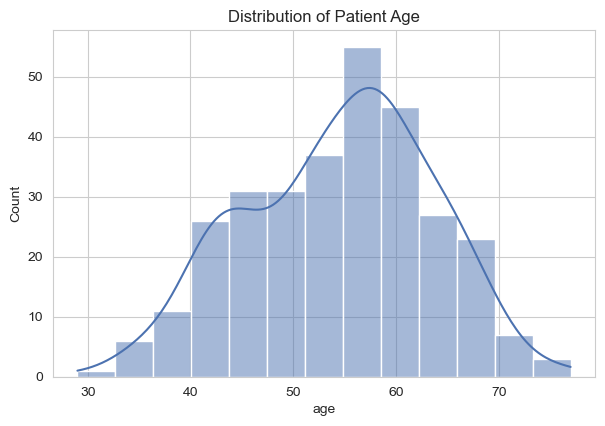

In [44]:
# 1. Distribution plot - Age
plt.figure(figsize=(7,4.5))
sns.histplot(df_clean["age"], kde=True, color="#4C72B0")
plt.title("Distribution of Patient Age")
plt.show()

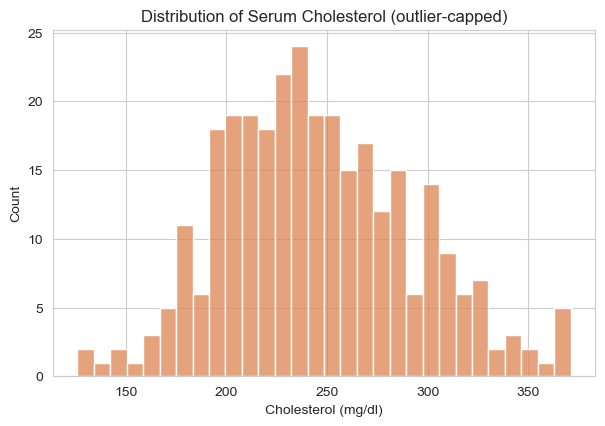

In [45]:
# 2. Histogram - Cholesterol
plt.figure(figsize=(7,4.5))
sns.histplot(df_clean["cholesterol"], bins=30, color="#DD8452")
plt.title("Distribution of Serum Cholesterol (outlier-capped)")
plt.xlabel("Cholesterol (mg/dl)")
plt.show()

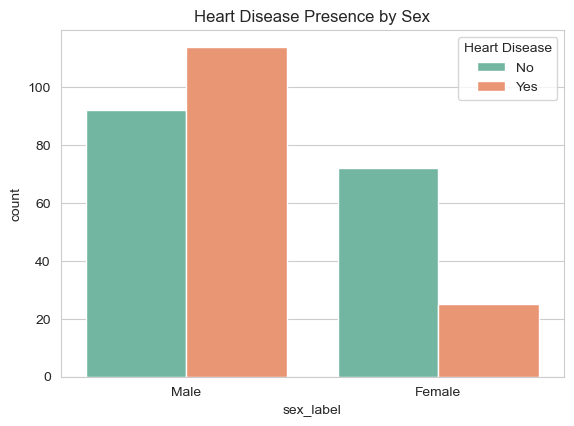

In [46]:
# 3. Bar chart - Heart disease count by sex
plt.figure(figsize=(6.5,4.5))
sns.countplot(data=df_clean, x="sex_label", hue="has_heart_disease", palette="Set2")
plt.title("Heart Disease Presence by Sex")
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.show()

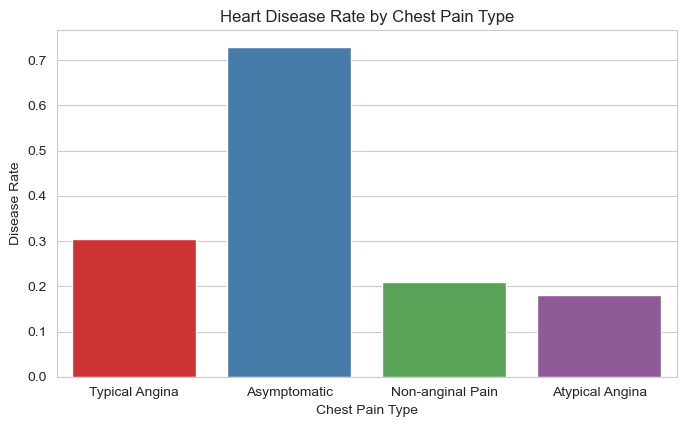

In [47]:
# 4. Category-wise analysis - Disease rate by chest pain type
plt.figure(figsize=(8,4.5))
sns.barplot(data=df_clean, x="chest_pain_label", y="has_heart_disease", hue="chest_pain_label",
            palette="Set1", legend=False, errorbar=None)
plt.title("Heart Disease Rate by Chest Pain Type")
plt.ylabel("Disease Rate")
plt.xlabel("Chest Pain Type")
plt.show()

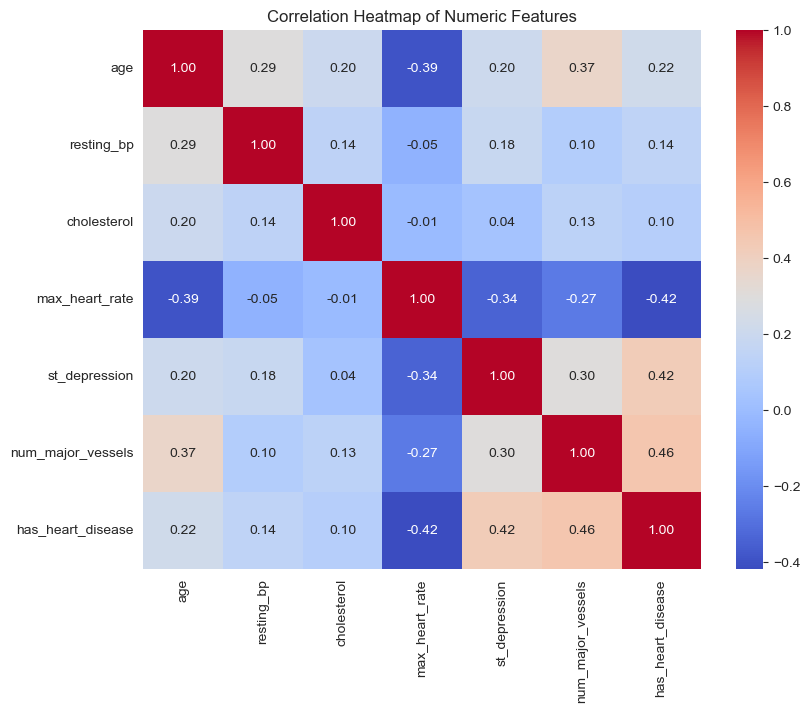

In [48]:
# 5. Correlation heatmap
plt.figure(figsize=(9,7))
numeric_cols = ["age", "resting_bp", "cholesterol", "max_heart_rate", "st_depression",
                 "num_major_vessels", "has_heart_disease"]
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

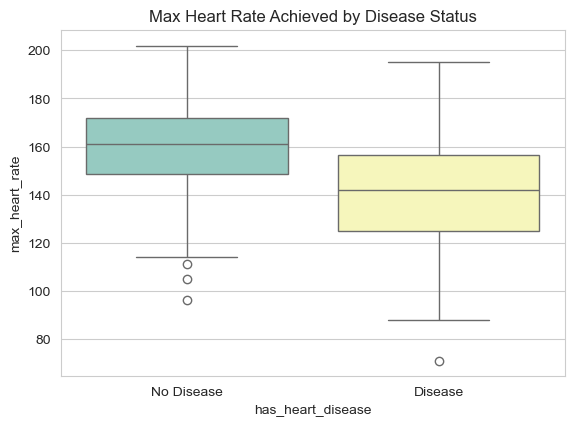

In [49]:
# 6. Boxplot - Max heart rate by disease status
plt.figure(figsize=(6.5,4.5))
sns.boxplot(data=df_clean, x="has_heart_disease", y="max_heart_rate", hue="has_heart_disease",
            palette="Set3", legend=False)
plt.xticks([0,1], ["No Disease", "Disease"])
plt.title("Max Heart Rate Achieved by Disease Status")
plt.show()

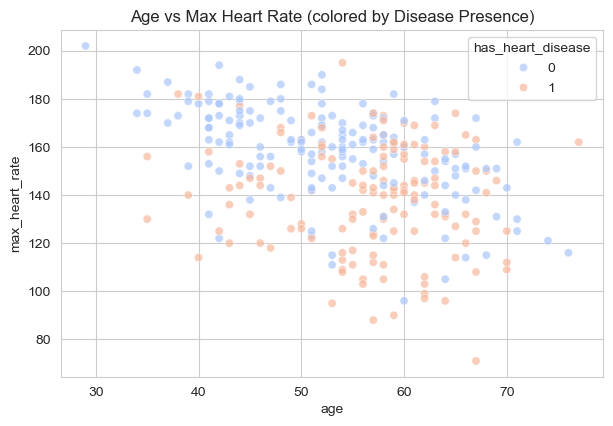

In [50]:
# 7. Scatter plot - Age vs Max Heart Rate colored by disease
plt.figure(figsize=(7,4.5))
sns.scatterplot(data=df_clean, x="age", y="max_heart_rate", hue="has_heart_disease", alpha=0.7, palette="coolwarm")
plt.title("Age vs Max Heart Rate (colored by Disease Presence)")
plt.show()

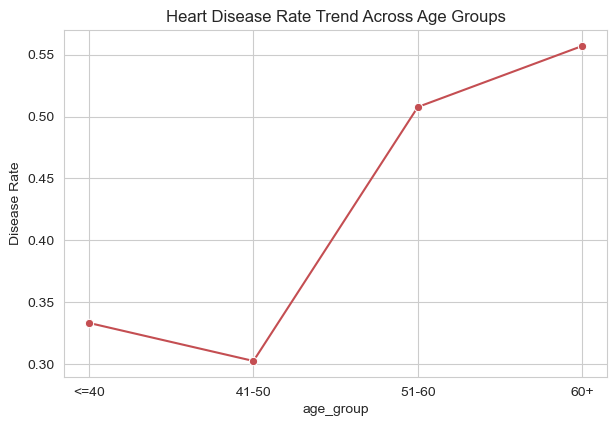

In [51]:
# 8. Line chart - Disease rate trend across age groups
age_trend = df_clean.groupby("age_group", observed=True)["has_heart_disease"].mean().reset_index()
plt.figure(figsize=(7,4.5))
sns.lineplot(data=age_trend, x="age_group", y="has_heart_disease", marker="o", color="#C44E52")
plt.title("Heart Disease Rate Trend Across Age Groups")
plt.ylabel("Disease Rate")
plt.show()

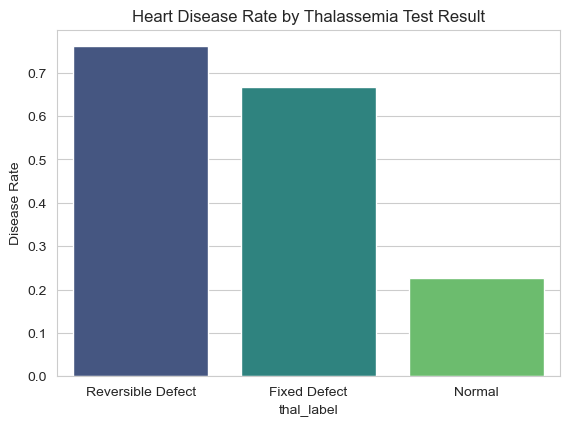

In [52]:
# 9. Top-performing categories - Disease rate by thalassemia result
thal_rate = (df_clean.groupby("thal_label", observed=True)["has_heart_disease"]
             .mean().sort_values(ascending=False).reset_index())
plt.figure(figsize=(6.5,4.5))
sns.barplot(data=thal_rate, x="thal_label", y="has_heart_disease", hue="thal_label",
            palette="viridis", legend=False)
plt.title("Heart Disease Rate by Thalassemia Test Result")
plt.ylabel("Disease Rate")
plt.show()

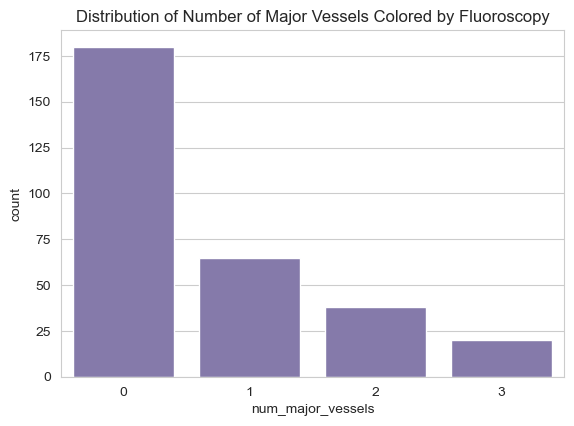

In [53]:
# 10. Countplot - Number of major vessels colored by fluoroscopy
plt.figure(figsize=(6.5,4.5))
sns.countplot(data=df_clean, x="num_major_vessels", color="#8172B2")
plt.title("Distribution of Number of Major Vessels Colored by Fluoroscopy")
plt.show()

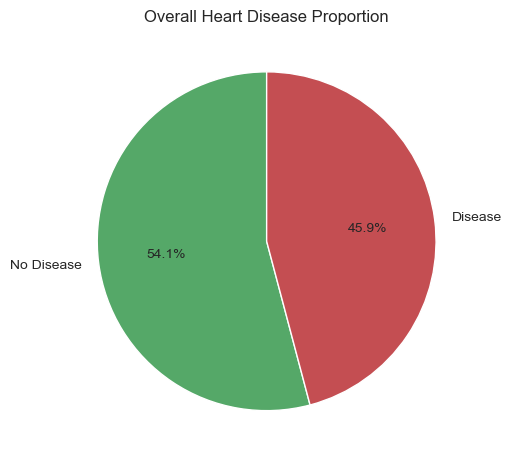

In [54]:
# 11. Pie chart - Overall heart disease proportion
counts = df_clean["has_heart_disease"].value_counts()
plt.figure(figsize=(5.5,5.5))
plt.pie(counts, labels=["No Disease", "Disease"], autopct="%1.1f%%",
        colors=["#55A868", "#C44E52"], startangle=90)
plt.title("Overall Heart Disease Proportion")
plt.show()

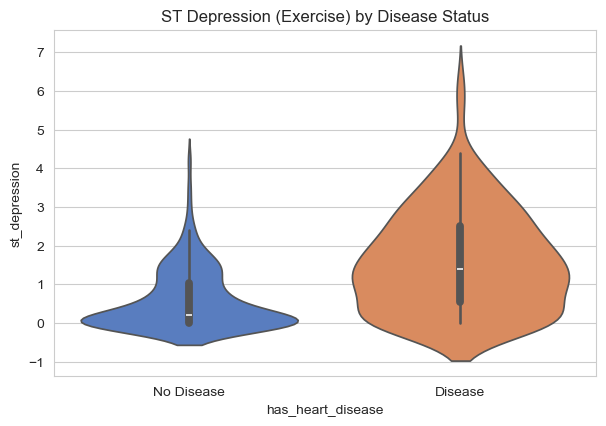

In [55]:
# 12. Violin plot - ST depression by disease status
plt.figure(figsize=(7,4.5))
sns.violinplot(data=df_clean, x="has_heart_disease", y="st_depression", hue="has_heart_disease",
               palette="muted", legend=False)
plt.xticks([0,1], ["No Disease", "Disease"])
plt.title("ST Depression (Exercise) by Disease Status")
plt.show()

## 6. Summary of Insights

- **Overall disease rate**: about **45.9%** of patients in this dataset were diagnosed with some stage of heart disease.
- **Sex is a strong risk indicator**: males had a disease rate of ~55% compared to ~26% for females.
- **Chest pain type is highly informative**: "asymptomatic" chest pain was associated with the *highest* disease rate, counter-intuitively — a pattern well documented in cardiology, since truly symptom-free presentations are often caught later.
- **Max heart rate achieved during exercise is inversely related to disease** (correlation ≈ −0.42): patients with disease tend to reach a lower peak heart rate.
- **ST depression (exercise-induced) and number of major vessels colored by fluoroscopy** are the two strongest positive correlates of disease (0.42 and 0.46 respectively), consistent with their clinical role as direct indicators of reduced blood flow.
- **Thalassemia test result** shows a clear gradient: "reversible defect" carries a substantially higher disease rate than "normal".
- **Age** shows a mild positive relationship with disease risk, rising through middle age, though sex and clinical test results are stronger predictors than age alone.

## 7. Challenges Faced and Solutions

| Challenge | Solution |
|---|---|
| UCI Machine Learning Repository's own servers were not directly reachable | Sourced the identical published dataset from a verified public GitHub mirror of the same UCI file. |
| `ca` (number of major vessels) and `thal` (thalassemia) columns used `?` to mark missing values and loaded as text | Converted to numeric with `errors="coerce"` and imputed the small number of missing entries with the column mode, since both are discrete clinical codes. |
| The original diagnosis label is multi-class (0-4, indicating disease severity) | Engineered a standard binary `has_heart_disease` target (0 = absent, 1 = present at any stage) alongside the original stage, matching how this dataset is conventionally analyzed. |
| Cholesterol and resting blood pressure contained clinically extreme outlier values | Applied IQR-based capping rather than deleting rows, preserving the full patient sample. |
| Categorical clinical codes (e.g. chest pain type 1-4) are hard to interpret in charts | Added human-readable label columns (`chest_pain_label`, `thal_label`, `sex_label`) purely for visualization, while keeping the original numeric codes intact for analysis. |